# Does a 100 m protected zone buy you anything at 50 m?

Four runs of the same encounter — a shallow 20° crossing between two multirotors — differing in
exactly two settings: the protected-zone radius the separation manager is told to keep
(`rpz = 50 m` or `100 m`) and the `MVP` margin it clears to (`1.05` or `1.00`). The **event scored
is the same in all four**: the running minimum separation dropping below **50 m**. So this is not
"how often does each one bust its own standard" — it is "how often does each one end up inside
50 m", which is the question you actually care about if 50 m is the real separation minimum and
everything above it is buffer.

All four are estimated with the fixed-effort IPS rare-event estimator (`opencdarr.parallel`), each
on **its own shell ladder** ending at the same 50 m event — see the next section for why that is
both correct and much faster than sharing one.

**Draft settings.** 3 replications, 2000 particles, `dt = 0.5 s` — enough to see the shape, not
enough for a publishable interval. A 3-replication log-space CI is indicative only.

In [20]:
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from opencdarr import cache
from opencdarr.cd import StateBased
from opencdarr.cns.navigation import GnssNavigation
from opencdarr.cr import MVP
from opencdarr.crr import FTR, PastCPA  # PastCPA kept for the commented-out alternative below
from opencdarr.fleet import Agent, build_env
from opencdarr.ips import Particle
from opencdarr.parallel import estimate_rare_prob
from opencdarr.performance import M600
from opencdarr.scenario import create_conflict
from opencdarr.state import AircraftState

## The scenario

One pinned encounter: two M600s, 20° crossing, zero design miss, loss of 50 m separation 70 s out,
3 m / 1 m/s GNSS self-fix error on each. `MVP` resolves, `FTR` recovers.

A 20° crossing is a slow, shallow geometry — closing speed is only `2 * gs * sin(10°) ≈ 3.6 m/s`, so
the pair spends a long time near CPA and `MVP` has plenty of time to work. That shows up in the
results as a distribution of achieved separations that hugs `rpz` tightly from above, with a thin
tail below it.

The geometry is built with `create_conflict(..., rpz=50.0)` in **all four** cases, so every run starts
from the identical world — `rpz` in `create_conflict` only sets where the initial range is placed, and
letting it move would confound the comparison. The only things that change are `build_env(rpz=...)`,
the radius `StateBased` detects against and `MVP` clears to, and `MVP(margin=...)`, the factor it
inflates that radius by when it does.

In [21]:
DPSI = 20.0  # crossing angle [deg]


def make_start(rpz: float, margin: float) -> Particle:
    """The one starting particle for a commanded protected-zone radius [m] and MVP margin."""
    own = AircraftState(id="OWN", lat=52.0, lon=4.0, trk=0.0, gs=10.2889,
                        pos_ci95=3.0, vel_ci95=1.0)
    intr = create_conflict(own, intr_id="INT", dpsi=DPSI, dcpa=0.0,
                           tlos=70.0, rpz=50.0, side=1)  # geometry pinned at 50 m for all configs
    agents = [Agent(own, M600), Agent(intr, M600)]
    env = build_env(agents, rpz=rpz, t_lookahead=60.0, dt=0.5,
                    detector=StateBased(), resolver=MVP(margin=margin),
                    # recovery=PastCPA(bouncing_guard=True), navigation=GnssNavigation(),
                    recovery=FTR(), navigation=GnssNavigation(),
                    done_timeout=10.0)
    return Particle(env=env, state=env.initial_state(agents))


EVENT = 50.0  # the scored event [m] — every ladder ends here, whatever else it does

# (rpz [m], MVP margin) — two radii x two margins
CONFIGS = [(50.0, 1.05), (100.0, 1.05), (50.0, 1.00), (100.0, 1.00)]

N_PARTICLES = 2000
REPS = 3
SEED = 20260802

## One ladder per configuration

Nothing requires two configurations to share a shell ladder. The estimate $\hat P = \prod_k S_k/N$ is
unbiased for the terminal shell whatever the intermediate shells are, so two runs on completely
different ladders still estimate the same $P(\min \text{sep} < 50\ \text{m})$ and their numbers are
directly comparable. Sharing a ladder only lines the curves up on identical $x$ values — worth very
little, and expensive: a shared ladder is by construction wrong for every configuration except the
one it was tuned for, and a shell whose survival is ~1 contributes a factor of ~1 to the product
while still costing a pass over all $N$ particles.

So each configuration gets its own. The cliff sits within a few metres of the radius `MVP` actually
clears to — `rpz * margin`, not `rpz` — so that is where the 1 m steps go; everywhere else is a
coarse geometric approach. Every ladder still ends at 50 m, which is all the comparison needs.

In [22]:
def _geometric(top: float, bottom: float, n: int) -> list[float]:
    """``n`` shells stepping geometrically from just below ``top`` down to ``bottom``."""
    return [top * (bottom / top) ** (k / n) for k in range(1, n + 1)]


def _linear(top: float, bottom: float, step: float) -> list[float]:
    """Shells stepping linearly from ``top - step`` down to ``bottom``."""
    return [top - step * k for k in range(1, max(1, round((top - bottom) / step)) + 1)]


def build_ladder(rpz: float, margin: float, event: float = EVENT,
                 n_coarse: int = 8, fine_step: float = 1.0) -> list[float]:
    """A shell ladder tuned to one configuration, ending at the scored ``event``.

    Coarse and geometric on the approach, 1 m through the cliff band around the cleared radius, then
    coarse again down to the event — those last shells are never reached when the configuration
    collapses, so they cost nothing and keep every ladder terminating at the same place.
    """
    cleared = rpz * margin
    top = max(1.6 * cleared, 1.25 * event)
    hi = min(top, max(cleared, event) + 3.0)   # a little above the cleared radius
    lo = max(event, cleared - 8.0)             # cliff band bottom, never below the event
    shells = _geometric(top, hi, n_coarse) + _linear(hi, lo, fine_step)
    if lo > event:
        shells += _geometric(lo, event, 5)
    shells.append(event)

    out: list[float] = []
    for d in shells:
        d = round(d * 2) / 2                   # snap to 0.5 m so the ladder reads cleanly
        if d >= event and (not out or d < out[-1]):
            out.append(d)
    if out[-1] != event:
        out.append(event)
    return out


LADDERS = {cfg: build_ladder(*cfg) for cfg in CONFIGS}
for cfg, ladder in LADDERS.items():
    print(f"rpz = {cfg[0]:5.0f} m, margin = {cfg[1]:.2f}: {len(ladder):2d} shells   {ladder}")

rpz =    50 m, margin = 1.05: 14 shells   [80.0, 75.5, 72.0, 68.5, 65.0, 61.5, 58.5, 55.5, 54.5, 53.5, 52.5, 51.5, 50.5, 50.0]
rpz =   100 m, margin = 1.05: 24 shells   [159.0, 150.5, 142.5, 134.5, 127.5, 120.5, 114.0, 108.0, 107.0, 106.0, 105.0, 104.0, 103.0, 102.0, 101.0, 100.0, 99.0, 98.0, 97.0, 85.0, 74.5, 65.0, 57.0, 50.0]
rpz =    50 m, margin = 1.00: 11 shells   [76.0, 72.0, 68.5, 65.0, 62.0, 58.5, 56.0, 53.0, 52.0, 51.0, 50.0]
rpz =   100 m, margin = 1.00: 24 shells   [151.5, 143.5, 135.5, 128.5, 121.5, 115.0, 109.0, 103.0, 102.0, 101.0, 100.0, 99.0, 98.0, 97.0, 96.0, 95.0, 94.0, 93.0, 92.0, 81.5, 72.0, 64.0, 56.5, 50.0]


## Estimates are cached to disk

Every estimate below goes through `opencdarr.cache`, which keys a result on the parameters that
determine it — geometry, CDR stack, CNS, `dt`, the ladder, particle and replication counts, the
seed — plus a fingerprint of the `opencdarr` source. So **re-running this notebook to redraw a
figure costs nothing**: the estimates load from `.opencdarr_cache/` (already in `.gitignore`) and
only the plotting cells actually do work.

Editing anything that changes a result still recomputes it, because the key changes: touch the
package, change a ladder, change `N_PARTICLES`, and that configuration is a cache miss. Editing
*this notebook's plotting code* is not part of the key, which is the whole point. Delete the
directory to force a clean recompute.

In [23]:
CACHE_DIR = Path(".opencdarr_cache")


def run_or_load(rpz: float, margin: float, ladder: list[float]):
    """The IPS estimate for one configuration, read from disk when this exact run is already there.

    Returns ``(estimate, was_cached, seconds)``. ``params`` has to name every value that determines
    the result — anything omitted here would let a changed setting silently return a stale number,
    which is the one way a cache can do damage.
    """
    params = {
        "scenario": "pairwise-crossing", "airframe": "M600", "gs": 10.2889,
        "dpsi": DPSI, "dcpa": 0.0, "tlos": 70.0, "rpz": rpz, "margin": margin,
        "detector": "StateBased", "resolver": "MVP", "recovery": "FTR",
        "navigation": "GnssNavigation", "pos_ci95": 3.0, "vel_ci95": 1.0,
        "t_lookahead": 60.0, "dt": 0.5, "done_timeout": 10.0,
        "levels": list(ladder), "n_particles": N_PARTICLES, "reps": REPS,
    }
    key = cache.run_key(params, seed=SEED)
    was_cached = (CACHE_DIR / f"{key}.pkl").exists()

    start = make_start(rpz, margin)
    t0 = time.perf_counter()
    est = cache.load_or_run(key, lambda: estimate_rare_prob(
        lambda seq, s=start: s, ladder,
        n_particles=N_PARTICLES, reps=REPS, seed=SEED, n_jobs=-1))
    return est, was_cached, time.perf_counter() - t0


def show(label: str, est, was_cached: bool, secs: float) -> None:
    """One result line, saying whether it was computed or loaded."""
    print(f"{label}   P(min sep < 50 m) = {est.prob:.2e}"
          f"   95% CI [{est.ci[0]:.2e}, {est.ci[1]:.2e}]"
          f"   collapsed {est.n_collapsed}/{REPS}"
          f"   ({'cached' if was_cached else f'{secs:.0f} s'})")

In [5]:
estimates = {}
for cfg in CONFIGS:
    rpz, margin = cfg
    est, was_cached, secs = run_or_load(rpz, margin, LADDERS[cfg])
    estimates[cfg] = est
    show(f"rpz = {rpz:5.0f} m  margin = {margin:.2f}", est, was_cached, secs)

rpz =    50 m  margin = 1.05   P(min sep < 50 m) = 4.88e-05   95% CI [3.88e-05, 6.00e-05]   collapsed 0/3   (cached)
rpz =   100 m  margin = 1.05   P(min sep < 50 m) = 0.00e+00   95% CI [0.00e+00, 0.00e+00]   collapsed 3/3   (cached)
rpz =    50 m  margin = 1.00   P(min sep < 50 m) = 3.59e-04   95% CI [2.57e-04, 4.78e-04]   collapsed 0/3   (cached)
rpz =   100 m  margin = 1.00   P(min sep < 50 m) = 0.00e+00   95% CI [0.00e+00, 0.00e+00]   collapsed 3/3   (cached)


A `P = 0` with **every replication collapsed** is not a probability of zero — it is the estimator
reporting that it ran out of particles before reaching 50 m. Which is itself informative: the cloud
never gets anywhere near 50 m.

So read the ladder instead of the endpoint. Each shell's cumulative product is
$P(\min \text{sep} < d)$ at that shell, and the shell where the survivors run out tells you where the
distribution's floor is.

In [24]:
def curve(est) -> tuple[list[float], list[float]]:
    """P(min sep < d) at each shell d, averaged over the replications that reached it."""
    dists, probs = [], []
    for k, d in enumerate(est.reps[0].levels):
        reached = [r for r in est.reps if k < len(r.survival) and r.survival[k] > 0.0]
        if not reached:
            break
        dists.append(d)
        probs.append(sum(math.prod(r.survival[: k + 1]) for r in reached) / len(reached))
    return dists, probs


curves = {cfg: curve(est) for cfg, est in estimates.items()}

for (rpz, margin), (dists, probs) in curves.items():
    print(f"\nrpz = {rpz:.0f} m, margin = {margin:.2f}")
    for d, p in zip(dists, probs):
        print(f"  P(min sep < {d:3.0f} m) = {p:.3e}")


rpz = 50 m, margin = 1.05
  P(min sep <  80 m) = 8.958e-01
  P(min sep <  76 m) = 8.094e-01
  P(min sep <  72 m) = 7.014e-01
  P(min sep <  68 m) = 5.706e-01
  P(min sep <  65 m) = 4.105e-01
  P(min sep <  62 m) = 2.435e-01
  P(min sep <  58 m) = 1.328e-01
  P(min sep <  56 m) = 4.344e-02
  P(min sep <  54 m) = 2.467e-02
  P(min sep <  54 m) = 1.109e-02
  P(min sep <  52 m) = 3.995e-03
  P(min sep <  52 m) = 1.066e-03
  P(min sep <  50 m) = 1.459e-04
  P(min sep <  50 m) = 4.881e-05

rpz = 100 m, margin = 1.05
  P(min sep < 159 m) = 9.857e-01
  P(min sep < 150 m) = 9.730e-01
  P(min sep < 142 m) = 9.377e-01
  P(min sep < 134 m) = 8.761e-01
  P(min sep < 128 m) = 7.485e-01
  P(min sep < 120 m) = 5.418e-01
  P(min sep < 114 m) = 2.918e-01
  P(min sep < 108 m) = 7.094e-02
  P(min sep < 107 m) = 4.904e-02
  P(min sep < 106 m) = 2.954e-02
  P(min sep < 105 m) = 1.610e-02
  P(min sep < 104 m) = 7.007e-03
  P(min sep < 103 m) = 2.480e-03
  P(min sep < 102 m) = 5.680e-04
  P(min sep < 101 m) 

## The 50 m answer, or a bound on it

A run that reached 50 m reports its estimate and CI. A run that collapsed stops at the last shell it
reached; one shell further, **zero** of `N_PARTICLES` survivors crossed, so the conditional crossing
probability there is bounded above by the rule of three, $3/N$ at 95% confidence. Since the running
minimum is monotone, everything below that shell — including 50 m — inherits the same bound.

In [25]:
def report(label: str, est, dists, probs, levels) -> tuple[float, float, bool]:
    """Print one configuration's 50 m answer; return (P or its upper bound, endpoint d, collapsed)."""
    d_last, p_last = dists[-1], probs[-1]
    if est.n_collapsed == 0:
        print(f"{label} P(min sep < 50 m) = {est.prob:.2e}  "
              f"95% CI [{est.ci[0]:.2e}, {est.ci[1]:.2e}]")
        return est.prob, d_last, False
    # every replication ran out of survivors; bound the rest of the ladder by the rule of three
    wall = levels[levels.index(d_last) + 1]
    bound = p_last * 3.0 / N_PARTICLES
    print(f"{label} collapsed at {wall:.0f} m — deepest reached {d_last:.0f} m "
          f"(P = {p_last:.2e}), no survivor below out of {N_PARTICLES}")
    print(f"{'':30}P(min sep < 50 m) <= P(min sep < {wall:.0f} m) < {bound:.1e}  (95%)")
    return bound, d_last, True


results = {
    cfg: report(f"rpz = {cfg[0]:5.0f} m, margin = {cfg[1]:.2f}:", estimates[cfg],
                *curves[cfg], LADDERS[cfg])
    for cfg in CONFIGS
}

print()
base = results[50.0, 1.00][0]
for cfg in CONFIGS[1:] + CONFIGS[:1]:
    if cfg == (50.0, 1.00):
        continue
    factor = base / results[cfg][0]
    rel = "at least " if results[cfg][2] else ""
    print(f"vs rpz = 50 m / margin 1.00, rpz = {cfg[0]:.0f} m / margin {cfg[1]:.2f} "
          f"is {rel}{factor:.0e}x safer against the same 50 m event")

rpz =    50 m, margin = 1.05: P(min sep < 50 m) = 4.88e-05  95% CI [3.88e-05, 6.00e-05]
rpz =   100 m, margin = 1.05: collapsed at 85 m — deepest reached 97 m (P = 3.10e-10), no survivor below out of 2000
                              P(min sep < 50 m) <= P(min sep < 85 m) < 4.7e-13  (95%)
rpz =    50 m, margin = 1.00: P(min sep < 50 m) = 3.59e-04  95% CI [2.57e-04, 4.78e-04]
rpz =   100 m, margin = 1.00: collapsed at 95 m — deepest reached 96 m (P = 7.27e-12), no survivor below out of 2000
                              P(min sep < 50 m) <= P(min sep < 95 m) < 1.1e-14  (95%)

vs rpz = 50 m / margin 1.00, rpz = 100 m / margin 1.05 is at least 8e+08x safer against the same 50 m event
vs rpz = 50 m / margin 1.00, rpz = 100 m / margin 1.00 is at least 3e+10x safer against the same 50 m event
vs rpz = 50 m / margin 1.00, rpz = 50 m / margin 1.05 is 7e+00x safer against the same 50 m event


## The four survival curves

$P(\min \text{sep} < d)$ against $d$, colour by commanded radius and line style by margin — solid is
`margin = 1.05`, dashed is `margin = 1.00`. The dotted vertical is the 50 m event being scored. A
star ends a curve that reached it; a downward triangle ends one that ran out of particles first,
and everything below that point is bounded rather than measured.

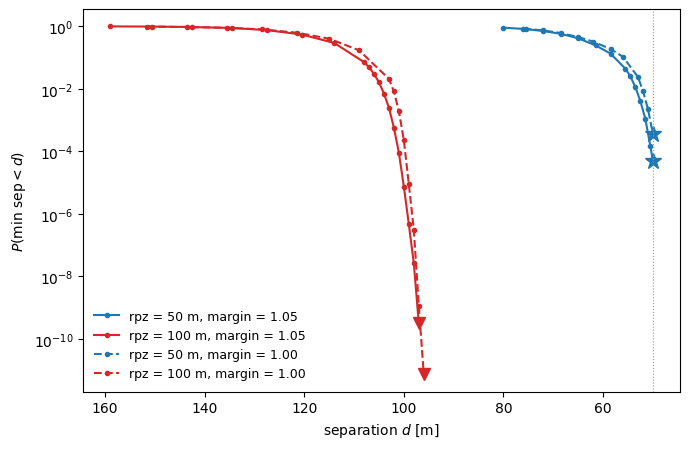

In [26]:
COLOUR = {50.0: "tab:blue", 100.0: "tab:red"}
STYLE = {1.05: "-", 1.00: "--"}

fig, ax = plt.subplots(figsize=(7.0, 4.6))

for cfg in CONFIGS:
    rpz, margin = cfg
    dists, probs = curves[cfg]
    _, _, collapsed = results[cfg]
    ax.plot(dists, probs, STYLE[margin], marker="o", ms=3.0, color=COLOUR[rpz],
            label=f"rpz = {rpz:.0f} m, margin = {margin:.2f}")
    # "v" marks a curve that ran out of particles; "*" marks one that reached the 50 m event
    ax.plot(dists[-1], probs[-1], "v" if collapsed else "*",
            ms=8 if collapsed else 12, color=COLOUR[rpz])

ax.axvline(50.0, color="0.6", lw=0.8, ls=":")
ax.set_yscale("log")
ax.set_xlabel("separation $d$ [m]")
ax.set_ylabel(r"$P(\min\ \mathrm{sep} < d)$")
ax.invert_xaxis()
ax.legend(frameon=False, loc="lower left", fontsize=9)
fig.tight_layout()
fig.savefig("rpz_50_vs_100.png", dpi=150)
plt.show()

## What it says

| rpz | margin | P(min sep < 50 m) | floor |
| --- | --- | --- | --- |
| 50 m | 1.05 | 4.88e-05  [3.88e-05, 6.00e-05] | crosses 50 m |
| 50 m | 1.00 | 3.59e-04  [2.57e-04, 4.78e-04] | crosses 50 m |
| 100 m | 1.05 | < 4.7e-13 | below 97 m — **not resolved**, see below |
| 100 m | 1.00 | < 1.1e-14 | 95–96 m |

**The radius and the margin are not the same lever.** Every curve falls off a cliff a few metres
below the radius `MVP` clears to, and the radius sets where that cliff sits. Going from 50 m to
100 m does not make the 50 m event some tens of times rarer — it moves the whole distribution's
floor to the mid-90s and the 50 m event stops being a tail event at all. It is outside the support
this model produces, which is why both red curves stop dead around 100 m.

The margin moves the tail, not the cliff. At `rpz = 50 m` it is worth a factor of ~7 on the 50 m
event (3.6e-04 → 4.9e-05), and the two blue curves are close to indistinguishable until the last
few metres — which is exactly where a margin is supposed to do something.

**One ladder artifact to be honest about.** The `rpz = 100 m / margin 1.05` run reports "collapsed
at 85 m", but that is *not* a floor at 85 m. Its fine band bottoms out at 97 m (`cleared - 8` with
`cleared = 105`), and the next shell down is a coarse 85 m — a 12 m jump that nothing was ever going
to survive. So its true floor is somewhere below 97 m and this run does not resolve it; the `< 4.7e-13`
bound is still valid, just loose, and it is *weaker* than the margin-1.00 bound only because the two
ladders happened to stop in different places. The margin-1.00 case, whose fine band reaches 92 m,
gives a genuine 1 m-resolved floor at 95–96 m. Fix for a rerun: extend the fine band to
`cleared - 15`, or make the coarse tail geometric with more steps.

**Caveats for the draft.** Three replications give a soft CI, and the log-space interval understates
the spread: the `rpz = 50 m / margin 1.05` point estimate came out 8.9e-05 on an earlier, coarser
shared ladder against 4.9e-05 here, with barely-overlapping intervals. IPS is unbiased either way, so
that gap is replication noise the 3-rep CI is not capturing rather than a ladder bias — but it means
these numbers are good to a factor of ~2, not better. `dt = 0.5 s` also carries discretisation bias.
For anything quotable: 10000 particles, 10 replications, `dt = 0.2`.

# Sweeping the protected-zone radius

The section above says the radius sets where the cliff sits. This section tests that directly:
**`rpz` = 125, 100, 75, 50 m, all at `margin = 1.00`**, everything else unchanged (still the 20°
crossing, still `MVP` + `FTR`), and still scored on the same 50 m event. If the cliff really tracks
the commanded radius, the four curves should be the same shape slid along the $d$ axis, and the
offset between each cliff and its radius should come out the same every time.

Margin 1.00 means `MVP` clears to exactly `rpz`, so the cliff position is the cleanest read on the
radius alone — no inflation factor in between. Four radii spanning 125 down to 50 m give three
independent checks of the offset above the scored event, plus the one case whose cliff lands on it.

In [27]:
RPZ_SWEEP = [125.0, 100.0, 75.0, 50.0]
SWEEP_MARGIN = 1.00

# Same generator, one ladder per radius. At margin 1.00 the cleared radius *is* rpz, so the fine
# band lands straight on each cliff. The sweep stops at 50 m because that is the scored event: a
# radius below it (25 m was tried and dropped) puts P(min sep < 50 m) at ~0.95, which is not a
# rare-event problem at all — plain Monte Carlo answers it in a fraction of the time, and it tells
# you nothing about where the cliff is that the other radii do not already show.
SWEEP_LADDERS = {rpz: build_ladder(rpz, SWEEP_MARGIN) for rpz in RPZ_SWEEP}
for rpz, ladder in SWEEP_LADDERS.items():
    print(f"rpz = {rpz:5.0f} m: {len(ladder):2d} shells   {ladder}")

print()
sweep_est = {}
for rpz in RPZ_SWEEP:
    est, was_cached, secs = run_or_load(rpz, SWEEP_MARGIN, SWEEP_LADDERS[rpz])
    sweep_est[rpz] = est
    show(f"rpz = {rpz:5.0f} m", est, was_cached, secs)

rpz =   125 m: 24 shells   [189.0, 179.0, 169.0, 160.0, 151.5, 143.0, 135.5, 128.0, 127.0, 126.0, 125.0, 124.0, 123.0, 122.0, 121.0, 120.0, 119.0, 118.0, 117.0, 98.5, 83.5, 70.5, 59.5, 50.0]
rpz =   100 m: 24 shells   [151.5, 143.5, 135.5, 128.5, 121.5, 115.0, 109.0, 103.0, 102.0, 101.0, 100.0, 99.0, 98.0, 97.0, 96.0, 95.0, 94.0, 93.0, 92.0, 81.5, 72.0, 64.0, 56.5, 50.0]
rpz =    75 m: 24 shells   [113.5, 107.5, 102.0, 96.5, 91.5, 87.0, 82.5, 78.0, 77.0, 76.0, 75.0, 74.0, 73.0, 72.0, 71.0, 70.0, 69.0, 68.0, 67.0, 63.0, 59.5, 56.0, 53.0, 50.0]
rpz =    50 m: 11 shells   [76.0, 72.0, 68.5, 65.0, 62.0, 58.5, 56.0, 53.0, 52.0, 51.0, 50.0]

rpz =   125 m   P(min sep < 50 m) = 0.00e+00   95% CI [0.00e+00, 0.00e+00]   collapsed 3/3   (cached)
rpz =   100 m   P(min sep < 50 m) = 0.00e+00   95% CI [0.00e+00, 0.00e+00]   collapsed 3/3   (cached)
rpz =    75 m   P(min sep < 50 m) = 0.00e+00   95% CI [0.00e+00, 0.00e+00]   collapsed 3/3   (cached)
rpz =    50 m   P(min sep < 50 m) = 3.59e-04   95%

In [28]:
sweep_curves = {rpz: curve(est) for rpz, est in sweep_est.items()}
sweep_results = {
    rpz: report(f"rpz = {rpz:5.0f} m:", sweep_est[rpz], *sweep_curves[rpz], SWEEP_LADDERS[rpz])
    for rpz in RPZ_SWEEP
}

print("\nwhere each configuration's distribution runs out:")
for rpz in RPZ_SWEEP:
    _, d_last, collapsed = sweep_results[rpz]
    if collapsed:
        wall = SWEEP_LADDERS[rpz][SWEEP_LADDERS[rpz].index(d_last) + 1]
        print(f"  rpz = {rpz:5.0f} m -> floor between {wall:.0f} and {d_last:.0f} m"
              f"   ({d_last - rpz:+.0f} m relative to rpz)")
    else:
        print(f"  rpz = {rpz:5.0f} m -> no floor above the 50 m event; it crosses")

rpz =   125 m: collapsed at 120 m — deepest reached 121 m (P = 6.38e-10), no survivor below out of 2000
                              P(min sep < 50 m) <= P(min sep < 120 m) < 9.6e-13  (95%)
rpz =   100 m: collapsed at 95 m — deepest reached 96 m (P = 7.27e-12), no survivor below out of 2000
                              P(min sep < 50 m) <= P(min sep < 95 m) < 1.1e-14  (95%)
rpz =    75 m: collapsed at 70 m — deepest reached 71 m (P = 4.90e-12), no survivor below out of 2000
                              P(min sep < 50 m) <= P(min sep < 70 m) < 7.3e-15  (95%)
rpz =    50 m: P(min sep < 50 m) = 3.59e-04  95% CI [2.57e-04, 4.78e-04]

where each configuration's distribution runs out:
  rpz =   125 m -> floor between 120 and 121 m   (-4 m relative to rpz)
  rpz =   100 m -> floor between 95 and 96 m   (-4 m relative to rpz)
  rpz =    75 m -> floor between 70 and 71 m   (-4 m relative to rpz)
  rpz =    50 m -> no floor above the 50 m event; it crosses


The four curves, one colour per radius from matplotlib's default cycle. Same reading as before: a
star ends a curve that reached the 50 m event, a triangle ends one that ran out of particles, the
faint vertical in each curve's colour is its commanded radius, and the dotted grey vertical is the
50 m threshold.

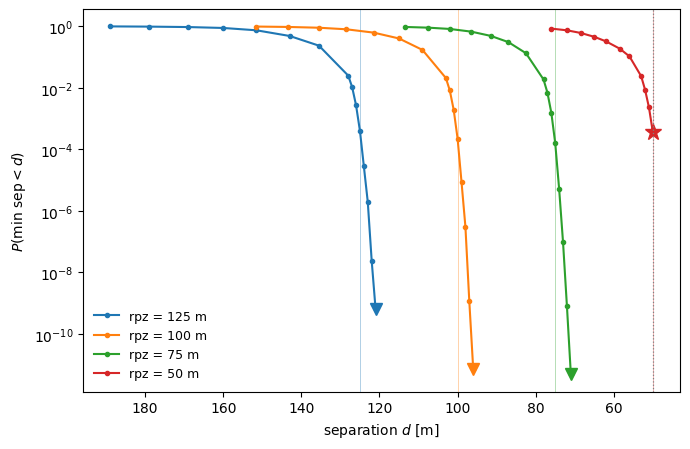

In [31]:
ramp = [f"C{i}" for i in range(len(RPZ_SWEEP))]

fig, ax = plt.subplots(figsize=(7.0, 4.6))

for rpz, colour in zip(RPZ_SWEEP, ramp):
    dists, probs = sweep_curves[rpz]
    _, _, collapsed = sweep_results[rpz]
    ax.plot(dists, probs, "-", marker="o", ms=3.0, color=colour, label=f"rpz = {rpz:.0f} m")
    ax.plot(dists[-1], probs[-1], "v" if collapsed else "*",
            ms=8 if collapsed else 12, color=colour)
    ax.axvline(rpz, color=colour, lw=0.7, ls="-", alpha=0.35)  # the commanded radius itself

ax.axvline(50.0, color="0.5", lw=0.9, ls=":")
ax.set_yscale("log")
ax.set_xlabel("separation $d$ [m]")
ax.set_ylabel(r"$P(\min\ \mathrm{sep} < d)$")
ax.invert_xaxis()
ax.legend(frameon=False, loc="lower left", fontsize=9,
          title_fontsize=9, alignment="left")
fig.tight_layout()
fig.savefig("rpz_sweep_margin_100.png", dpi=150)
plt.show()

## What the sweep says

| rpz | P(min sep < 50 m) | floor | offset from rpz |
| --- | --- | --- | --- |
| 125 m | < 9.6e-13 | 120–121 m | −4 m |
| 100 m | < 1.1e-14 | 95–96 m | −4 m |
| 75 m | < 7.3e-15 | 70–71 m | −4 m |
| 50 m | 3.59e-04  [2.57e-04, 4.78e-04] | crosses 50 m | — |

**The cliff tracks the radius at a constant −4 m.** Three radii, three collapses, the same offset
every time — and each was resolved to 1 m by its own independently-built ladder, so the agreement is
measured rather than imposed. The four curves in the figure are one shape translated along the $d$
axis. That is the claim the first section made from two points; this is it at four, spanning a
factor of 2.5 in radius.

The offset being *constant in metres* rather than proportional to `rpz` is the interesting part. It
says the depth of the excursion below the cleared radius is set by the CNS error and the resolver's
behaviour once inside the zone, not by the size of the zone — which is what you would expect from a
fixed 3 m GNSS self-fix error, and it means the margin needed to protect a given threshold does not
have to grow with the radius.

**The three bounds are not comparable to each other.** `rpz = 125 m` reports `< 9.6e-13` and
`rpz = 75 m` reports `< 7.3e-15`; that does **not** make 75 m the safer setting. Each bound is
`P(deepest shell reached) × 3/N`, so it records how far into its own tail that ladder got before
running out of particles, not a physical probability. The honest statement is the same for all
three: the 50 m event is outside the support, and each number is only an upper bound on its own
configuration.

**Only `rpz = 50 m` produces a real number**, because it is the only one whose cliff lands on the
threshold being scored. So `P(min sep < 50 m)` is close to a step function in the radius: impossible
at 75 m and above, a thin 3.6e-04 tail at 50 m. If you want to trade radius against a target
probability at 50 m, the range worth sweeping is roughly 50–60 m — the −4 m offset says the cliff
leaves the threshold as soon as the radius clears ~54 m.

*(An `rpz = 25 m` case was tried and dropped: it puts `P` at ~0.95, which is not a rare-event problem
— plain Monte Carlo answers it far faster — and it contributes no cliff above the scored event.)*